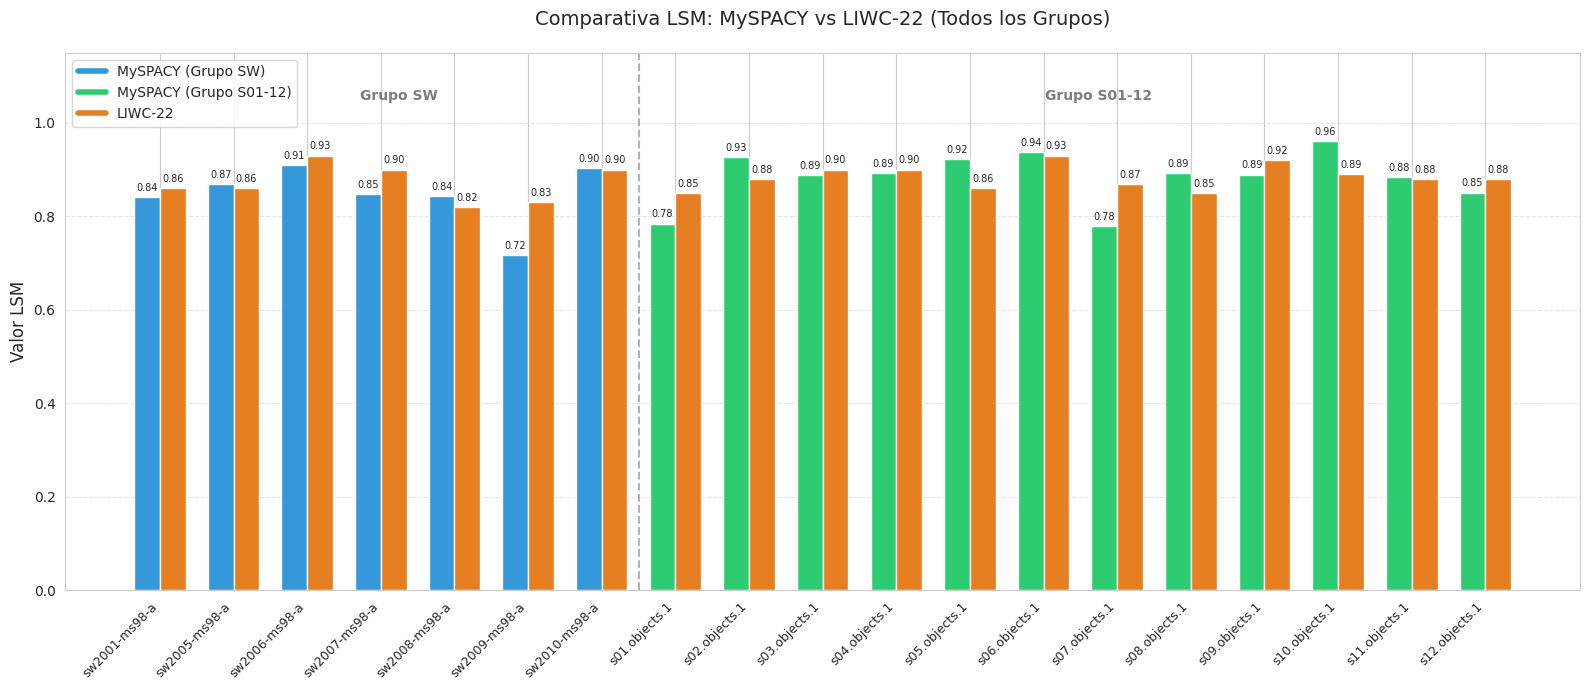

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_completo_comparativo(csv_path):
    # 1. Cargar datos
    df = pd.read_csv(csv_path)
    
    # 2. Ordenar para que aparezca primero un grupo y luego el otro
    # Ordenamos por 'grupo' (output primero, out después) y luego por archivo
    df = df.sort_values(by=['grupo', 'archivo'], ascending=[False, True]).reset_index(drop=True)
    
    # Limpiamos nombres de archivo
    df['archivo_corto'] = df['archivo'].str.replace('.txt', '', regex=False)

    # 3. Configuración de las barras
    x = np.arange(len(df['archivo_corto']))
    width = 0.35

    fig, ax = plt.subplots(figsize=(16, 7))
    
    # 4. Definir colores dinámicos para MySPACY
    # Azul (#3498db) para el grupo 'output' (sw) y Verde (#2ecc71) para 'out' (s01...)
    colores_spacy = ['#3498db' if g == 'output' else '#2ecc71' for g in df['grupo']]
    
    # Creamos las barras
    # Pasamos la lista de colores a la primera serie de barras
    rects1 = ax.bar(x - width/2, df['lsm_spacy'], width, label='MySPACY', color=colores_spacy)
    rects2 = ax.bar(x + width/2, df['lsm_liwc'], width, label='LIWC-22', color='#e67e22')

    # 5. Detalles del diseño
    ax.set_ylabel('Valor LSM', fontsize=12)
    ax.set_title('Comparativa LSM: MySPACY vs LIWC-22 (Todos los Grupos)', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(df['archivo_corto'], rotation=45, ha='right', fontsize=9)
    
    # Crear una leyenda personalizada para explicar los colores
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='#3498db', lw=4, label='MySPACY (Grupo SW)'),
        Line2D([0], [0], color='#2ecc71', lw=4, label='MySPACY (Grupo S01-12)'),
        Line2D([0], [0], color='#e67e22', lw=4, label='LIWC-22')
    ]
    ax.legend(handles=legend_elements, loc='upper left')

    # Añadir valores sobre las barras
    ax.bar_label(rects1, padding=3, fmt='%.2f', fontsize=7)
    ax.bar_label(rects2, padding=3, fmt='%.2f', fontsize=7)

    # Línea divisoria visual entre grupos (opcional)
    punto_corte = len(df[df['grupo'] == 'output']) - 0.5
    ax.axvline(x=punto_corte, color='black', linestyle='--', alpha=0.3)
    ax.text(punto_corte/2, 1.05, "Grupo SW", ha='center', fontweight='bold', alpha=0.6)
    ax.text(punto_corte + (len(df)-punto_corte)/2, 1.05, "Grupo S01-12", ha='center', fontweight='bold', alpha=0.6)

    ax.set_ylim(0, 1.15)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    plt.savefig('comparativa_total_barras.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_completo_comparativo("/home/tgallo/Documents/Proyecto_modular/datos_para_plotear.csv")